   After each instruction finishes at its terminal state, the FSM jumps back
   to state 0 to fetch the next instruction. Each state specifies exactly which
   control signals are asserted -- for example, state 0 asserts PCWrite, IRWrite
   , MemRead (to fetch the instruction and update PC), while state 6 asserts
   MemRead and IorD=1 (to read data memory using the computed address in ALUOut)

   The FSM is implemented as combinational logic (a ROM or PLA) plus a 4-bit state
   register. The inputs are the 7-bit opcode + 4-bit current state (11 bits
   total), and the outputs are the 15 control signals + 4-bit next state (19
   bits total). It is bigger than the single-cycle control unit, but the 
   trade-off is worth it: faster average execution and less hardware duplication


THE TRADE-OFF SUMMARY   
   ... // Single-Cycle // Multi-Cycle
   Clock Period // Long (slowest instruction) // Short (slowest stage)
   Cycles per instruction // Always 1 // 3-5 depending on type
   Memory // Separate insrtr + data // Shared (reused)
   ALU // Used once // Reused across cycles
   Extra Registers // None // IR, A, B, ALUOut, MDR
   Control Unit // Combinational (simple) // FSM with state (complex)
   Average Speed // Slower // Faster

   The distinction between ALU and ALUOut is ... important concepts for the
   MULTI-CYCLE DATAPATH. In a single-cycle design, these wouldn't need to be
   separated, but because ... the module breaks instructions into multiple
   clock cycles, you need a place to "park" data so it doesn't get lost when the 
   clock ticks.

   The ALU (ARITHMETIC LOGIC UNIT) is the "combinational" logic--the actual
   calculator. It takes two inputs and produces a result almost instantly based 
   on the `ALUOp` signals. However, as soon as the clock cycle ends and a new
   state begins, the inputs to the ALU might change. For example, in an R-type
   instruction, once you move from `Cycle 3 (Execute)` to `Cycle 4 (Write-back)`
   , the registers might stop outputting the data you just calculated. 

   ALUOut is a REGISTRER (a storage element), not a calculator. Its only job is
   to capture the output of the ALU at the end of a clock cycle and hold onto it
   so it's available for the next cycle. In ... you can see the little triangle
   symbol under ALUOut -- that indicate it is clock-triggered. During CYCLE 3,
   the ALU does the math, and at the very end of that cycle, that result is
   "latched" into the ALUOut register.

   Think of it like this: ... ALU is like a chef who cooks a dish (the result).#
   If there's no counter to put the dish on, the chef starts the next order and 
   the first dish is gone. ALUOut is the counter. It holds the "dish" steady
   while the CPU prepares to write it back to the Register File or use it as a 
   memory address in a later cycle. Without ALUOut, the result wopuld vanish 
   befoire the CPU had a chance...
      

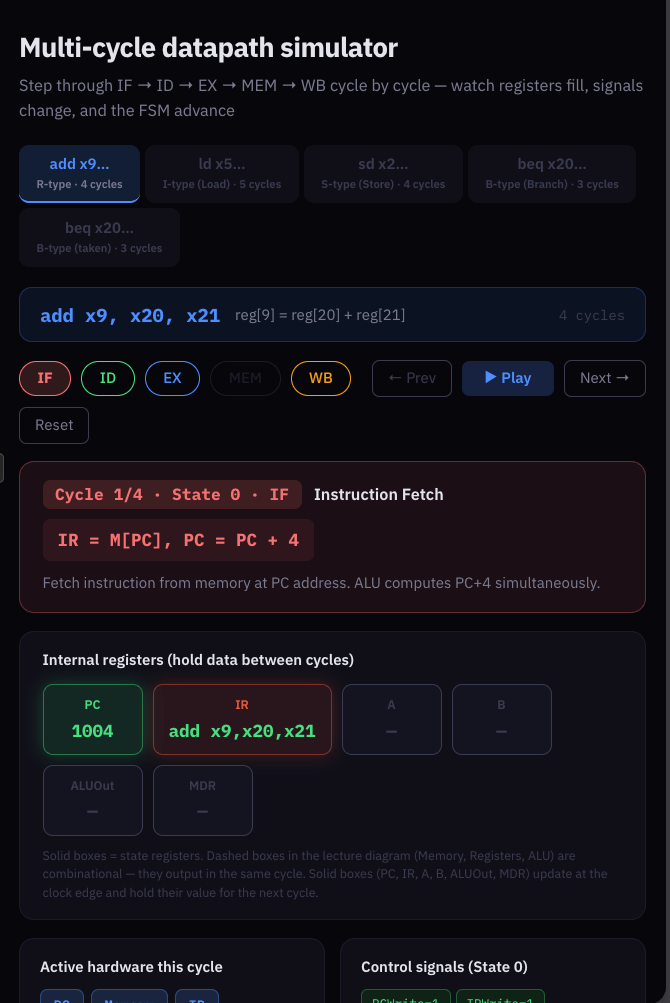

... 

### WALK-THROUGH: Load (`ld x5, 40(x1)`)
   ... At each step, pay attention to four things changing simulatenously: the
   STAGE PILLS at the top (shoiwing where you are in 
   IF -> ID -> EX -> MEM -> WB), the INTERNAL REGISTERS (lighting up green when 
   they get written), the FSM STATE DIAGRAM (the current sate pulses), and the
   CONTROL SIGNALS panel. 

   ... 

   (omitted due to lack of time)


### The FSM diagram
   The bottom panel shows all 11 states. Your instruction's path is highlighted
   with solid arrows -- the states it visits lights up as you step through. All
   instructions share states 0 and 1 (IF and ID are universal), then branch out
   to different states depending on the opcode. After the final state, the FSM 
   loops back to state 0 for the next instruction.

   This is the key difference from single-cycle: the control unit isn't just a
   combinational truth table anymore -- it's a STATE MACHINE that remembers 
   which cycle it's in and outputs different control signals each cycle. 11 
   states, 15 control signals, one state register -- that's the entire 
   multi-cycle control unit. 

### IMPLEMENTING THE FSM: ROM
   The FSM control unit is just a combinational logic (to compute outputs +
   next state) plus a 4-bit state register. The question is: how do you build
   that combinational logic in actual hardware?

   The simplest approach is a ROM (Read Only Memory). Think of it as a giant
   lookup table burned into silicon. The ROM's address lines are the 11 input
   bits (7-bit opcode + 4-bit current state), and the data lines are the 19
   output bits (15 control signals + 4 bit next state). That's a ROM with 2^11
   = 2048 entries, each 19 bits wide. For every possible combination of opcode
   and current state, the ROM stores the exact control signals and next state to
   output. No logic gates, no design effort -- just a table.

   ROM variants your lecture mentions: EPROM (erasable with UC light, Intel
   invented in 1971 with 2048 bits) and FLASH MEMORY (electrically erasable,
   started with Toshiba's 4Mb NAND in 1989, now up to 4TB). These are the same
   technology behind USB drives and SSDs -- the "read only" name is historical
   since Flash is clearly writable, just not as fast as RAM. 

   The downside of ROM is waste: most of those 2048 entries are don't cares
   (invalid opcode + state combinations that never occur). A PLA (Programmable
   Logic Array) would be more space-efficient since it only encodes the rows
   that actually matter, but ROMs are simpler to manufacture. Your lecture hints
   that there's an even better alternative -- microprogramming -- which is
   covered in the next lecture.


### EXAMPLE RISC-V Processor (Rocket Tile)
   Page 40 shows a real RISC-V processor called "Rocket" built by UCB. The key
   blocks map directly to what you've learned: the INTEGER UNIT contains the
   ALU and a multiply/divide unit (exactly what you built in lecture 4-5), the
   INSTRUCTION FETCH and INSTRUCTION DECODE stages are visible, but there's a
   WRITE BACK stage. The two large blocks on the right are `dcache` (data cache
   -- the fast on-chip data memory) and `icache` (instruction cache -- fast 
   on-chip instruction memory). In multi-cycle these would be the single shared
   memory; in a real pipelined processor they're separated again for performance

   The FPU (Floating Point Unit) handles decimal arithmetic -- beyond this 
   module's scope but it's essentially another ALU specialised for flaots. The
   Control and Status Registers (CSR) handle system-level tasks like interrupts
   and privilegde modes -- also beyond scope, but ... 

   The takeaway: everything you've learned -- ALU, datapath, control unit, 
   memory -- maps directly into real silicon. Rocket is an actual tapeout-ready
   RISC-V processor, and its architecture diagram is just a mor detailed version
   of the diagrams you've been building interactive simulators for. That's the 
   whole module story in one chip. 

---

-- In the context of the multi-cycle datapath, `IorD` (Instruction or Data) is a
   multiplexer control signal that decides whether the memory address comes from
   the PROGRAM COUNTER (to fetch an instruction) or from the ALU OUTPUT (to
   access a data variable for `lw` or `sw`). MemRead is the command send to 
   memory telling it to putput the data at the selected address, which is active 
   during the Fetch state and the Load-Memory state. These signals are generated
   by the Control Unit, which is typically implemented as a ROM (Read-Only 
   Memory) or a PLA (Programmable Logic Array); these act as a "lookup table"
   where the input is the current state and he instruction opcode, and the 
   output is the specific pattern of 1s and 0s (the control signals) needed to
   move data through the datapath for that specific step. 

-- ... the MULTI-CYCLE DATAPATH. Instead of trying to cram everything into one
   long clock cycle (which would be slow), we break each instruction into 
   smaller steps.

   The Control Unit (FSM) coordinates this. ...


   THE "FETCH & DECODE" FOUNDATION (States 0-1)
      Every instruction, no matter what it is, starts here:

      1. STATE 0 (Fetch): The CPU fetches the instruction from memory at the 
         current PC and moves it into the Instruction Register (IR). It also
         increments the PC (PC = PC + 4).
      2. STATE 1 (Decode): The Control Unit looks at the `opcode`. While it's
         decoding, the ALU pre-calculates the branch target address just in case
         it's a branch.


   ---
   MEMORY ACCESS: `lw` and `sw` (States 2-5)
      3. STATE 2 (Mem Address): The ALU adds the base register and the offset to
         find the memory address.
      4. STATE 3 (LW Read): For `lw`, the CPU reads the data from that memory
         address.
      5. STATE 4 (LW Write-back): The data read from memory is finally saved 
         into the destination register (`rd`).
      6. STATE 5 (SW Write): For `sw`, the CPU takes the value from a register
         and writes it into the memory address calculated in State 2. 


   ---
   ARITHMETIC: R-type (States 6-7)
      7. STATE 6 (Execution): The ALU performs the actual math (e.g.,
         `x2 + x3`)     <-- `rs1 operand rs2`
      8. STATE 7 (R-type Write-back): The result of that math is stored in the
         destination regiser (`rd`).


   ---
   CONTROL FLOW: Branch && Jump
      9. STATE 8 (Branch): The ALU subtracts the two registers. If the result is
         zero (meaning they are equal), the PC is updated with the branch target
         address calculated in STATE 1.
      10. STATE 9 (JAL - Jump AND Link): The CPU saves the "return address" 
          (`PC + 4`) into a register and jumpts to the target address.
      11. STATE 10 (JALR): Similar to JAL, but the jump target is calculated by
          adding an offset to a register value (used for function returns or
          pointers).


   ---
   WHY DOES THIS MATTER FOR YOUR EXAM?
      Because different instructions take a different number of states!
         - `lw` is the "slowest" (5 states/cycles).
         - `sw` and R-type takes 4 cycles.
         - `beq` takes only 3 cycles.
                   


---

---

# LECTURE 8: Microprogram and Microsequencer


THE PROBLEM: FSM state diagrams are a mess
   Remember our multi-cycle control unit from L7? We had that FSM with 11 states
   (0-10), and each state had a bunch of raw control signal assignments like
   `ALUSrcA=01, ALUSrcB=10, ALUOp=10`. it works. but it's got two problems.

   1. IT'S HARD TO READ. Looking at `ALUSrcA=1, ALUSrcB=10, ALUOp=10` tells you
      nothing about what's actually happening. You have to manually decode each
      signal. Is ALUSrcA=1 the PC or register A? You have to remember.
   2. IT SCALES TERRIBLY. With just 6 instruction types we already have 11 
      states. A real ISA with dozens of instructions would make this diagram an
      absolute nightmare.

   So the lecturer asks: can we describe the same control logic in a more 
   program-like way?


THE FIX: fields -- giving control signals human-readable names
   The key insight is beautifully simple. Instead of writing raw signal values,
   we GROUP RELATED CONTROL SIGNALS INTO FIELDS and give them meaningful names.
   Think of it like refactoring messy code -- same behavior, much more 
   readable. 

   For example, state 3 (I-type execute) had: `ALUSrcA=01, ALUSrcB=10, ALUOp=10`
   . That's three separate signal assignments you have to decode. Instead, we
   define three FIELDS:
      
   * SRC1 = A --> means ALUSrcA = 1 (the ALU's first input comes from Register A)
   * SRC2 = ImmGen --> means ALUSrcB = 10 (second input comes from the immediate
     generator)
   * ALUCtrl = funct --> means ALUOp = 10 (ALU operation determined by funct
     field).

   Same hardware behaviorm but now when you read 
   `SRC1=A, SRC2=ImmGen, ALUCtrl=funct` you immediately understand: "take
   register A, take the immediate, do whatever operation funct says."

   There are 7 FIELDS total, split into two groups:

   ALU-related fields (what to compute): 
      * ALUCtrl: add / subt / funct --> controls ALUOp
      * SRC1: PC / A                --> controls ALUSrcA
      * SRC2: B / 4 / ImmGen        --> controls ALUSrcB

---
   Read/Write/Sequencing fields (what to read, write, where to go next):
      * `Memory`: ReadPC / ReadALU / WriteALU --> bundles MemRead, IorD, IRWrite,
        MemWrite
      * `RegCtrl`: Read / WriteALU / WriteMDR --> bundles RegWrite, MemtoReg, 
        register reads
      * `PCWriteCtrl`: ALU / ALUOutCond / ALUOut --> bundles PCWrite, 
        PCWriteCond, PCSrc
      * `Sequencing`: how to determine the next step

   This really clever bit is that one field assignment can map to multiple 
   control signals. For instance, `Memory = ReadPC` expands to three signals at
   once: M,emread=1, IorD=0, IRWrite=1. It's like calling a function instead of
   writing inline code -- same effect, much cleaner.


THE SEQUENCING FIELD: "where do I go next?"
   This is the part that makes the microprogram work like actual code. There are
   5 possible values for the Sequencing field:

   1. `seq` -- next state = current state + 1. Like falling through to the next
      line of code. Used when states are natually sequential (e.g., state 0 
      -> state 1).
   2. `dispatch1` -- look up the opcode in a jump table (Dispatch ROM 1) to 
      determine the next state. This is the big fan-out from state 1 (decode)
      where we branch to different paths for R-type, I-type, load, store,
      branch, jump.
   3. `dispatch2` -- a second, smaller jump table (Dispatch ROM 2) used after 
      the load/store address calculation in state 5, branching to either state 6
      (load memory) or state 8 (store memory).
   4. `fetch` -- unconditionally go back to state 0. Used when an instruction
      is done (states 4, 7, 8, 9, 10 all loop back to fetch).#
   5. `R/I-wb` -- go to state 4 (the register writeback state). This is a 
      specific shortcut used by state 2 (R-type execute --> R-type writeback).


   ... map perfectly to familiar programming concepts: `seq` is fallthrough,
   `dispatch` is a switch statement, `fetch`is a return/goto and `R/I-wb` is a 
   specific goto.



THE MICROPROGRAM TABLE: the whole FSM in 11 rows
   Now here's the payoff... Instead of drawing tangled state diagram, we can
   write the entire control logic as a compact TABLE -- the microprogram. Each
   row is one state (one "micro-instruction"), and the columns are the 7 fields...

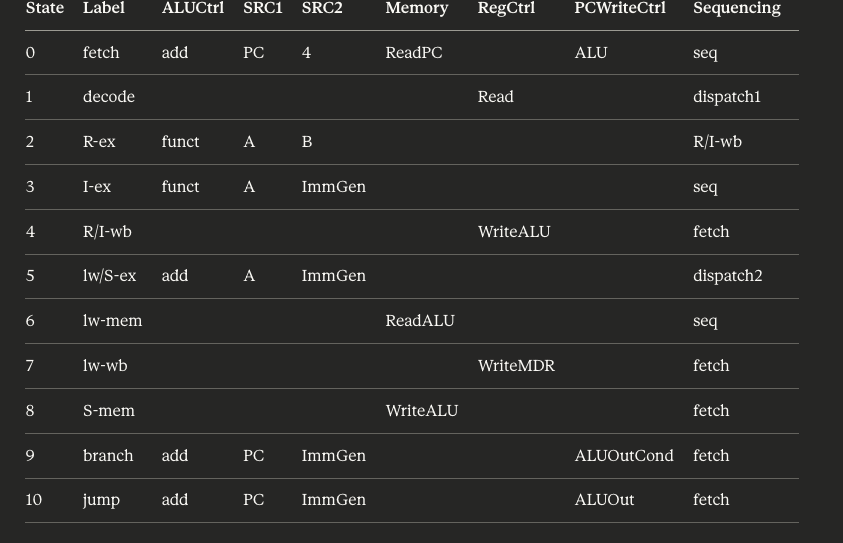

   ... The entire multi-cycle control unit in 11 lines. Empty cells mean
   "don't care" -- those fields aren't active in that state. You can trace any
   instruction by just folloing the `Sequencing` column to see which row you jump 
   to next.

   For example, tracing a LOAD instruction: row 0 (fetch, seq->) --> row 1 
   (decode, dispatch1 --> lw->) --> row 5 (lw/S-ex) ... Five cycles, five rows.




---

-- It is completely normal to be confused by this -- this transition from 
   drawing circles for FSMs to looking at a microprogram table is a massive leap
   ... correct: Dispatch ROMs are just lookup tables acting as traffic cops for
   your FSM.

   ... breakdown... 


   1. The 7-bit to 4-bit Mystery
      ... bit counts are correct. Here is why a Dispatch ROM takes 7 bits in and
      spits 4 bits out:
         * Input (7 bits): This is the RISC-V instruction `opcode`. The Dispatch
           ROM needs to look at the opcode to figure out what kind of #
           instruction we are dealing with. 
         * OUTPUT (4 bits): This is the STATE NUMBER the FSM needs to jump to
           next. Because this specific datapath only has 11 states (labeled 0
           to 10), we only need 4 bits of binary to represent those numbers
           (2^4 = 16 possible states)


   2. How it Maps to Your Table (The "Sequencing" Column)
      Look at the far-right column in your screenshot... labeled "SEQUENCING".
      This tells the hardware how to find the state when the current clock
      cycle ends.

      Here is what Dispatch 1 and Dispatch 2 are actually doing in that table:
         * DISPATCH ROM 1 (The big split): Look at `STATE 1 (decode)`. The 
           sequencing is `dispatch1`. At this point, the CPU just fetched the 
           instruction and doesn't know what it is yet. The Dispatch 1 ROM takes
           the 7-bit opcode and outputs the next state.
              - If opcode = R-type, it outputs State 2.
              - If opcode = I-type, it outputs State 3. 
              - If opcode = Load/Store, it outputs State 5. 
              - If opcode = Branch, it outputs State 9.
         * DISPATCH ROM 2 (The Load/Store Split):      
           Look at `State 5 (lw/S-ex)`. Notice how both `lw` and `sw` share this
           exact same state to calculate their memory address. Once the address
           is calculated, they have to part ways. The sequencing here is 
           `dispatch2`. It looks at the opcode again to make a secondary routing
           decision:
              - If opcode = Load (`lw`), it outputs State 6 (`lw-mem`).
              - If opcode = Store (`sw`), it outputs State 8 (`S-mem`).

   3. The MUX and Timing
      Yes, ONLY ONE IS USED PER MICRO-CYCLE! Inside the Control Unit, there is a
      register keeping track of the current State (let's call it the micro-PC).
      There is a MUX sitting right in front of this register that decides what 
      the next state will be. The MUX options typically match the words in your
                                            <-- need to see micro-PC as holding addresses
                                                ... idk why I started assosciate the micro-PC
                                                with time, lol. maybe it's because of the
                                                $\micro$ sign that reminds me of microseconds.
      Sequencing column:
         1. `seq`: Just add 1 to the current state (e.g., State 0 goes to 
            State 1).
         2. `fetch`: Hardcode to jump back to State 0 to start a new instruction
         3. `dispatch1`: Pass through the 4-bit output of Dispatch ROM 1.
         4. `dispatch2`: Pass through the 4-bit output of Dispatch ROM 2.
     
     The hardware reads the current row in your table, sees the word in the 
     Sequencing column, and uses that to flip the MUX switch to the correct
     wire. 


-- Gemini said
That is a brilliant question. You have just stumbled onto one of the most fundamental distinctions in computer engineering: the difference between the Instruction Set Architecture (ISA) and the Microarchitecture.

The short answer is: The 7-bit opcode belongs to the software standard, while the 4-bit state number belongs to your specific hardware design. Here is the breakdown of why they are different sizes:

1. The 7-bit Opcode (The Global Standard)
The 7-bit opcode is dictated by the RISC-V ISA. This is the universal "contract" that all software compilers (like GCC or Clang) agree to use.

7 bits gives RISC-V 2 
7
 =128 possible opcode categories.

RISC-V needs all 128 of those slots! While your module focuses on the basic integer instructions (RV32I), a real-world processor also has floating-point math, vector processing, atomic memory operations, and room reserved for future custom extensions.

If the opcode were only 4 bits, the entire RISC-V language would be limited to just 16 types of instructions forever.


---
   2. The 4-bit State (The Local Hardware)
      The 11 states belong to the MICROARCHITECTURE -- the physical way this
      specific textbook processor was built to execute that software contract.
      * Yes... course is simplifying things... The 11-state fsm is a classic
        academic model designed to teach you the concept of multi-cycle routing
        without overwhelming you.
      * A real, modern Intel or Apple Silicon processor doesn't have 11 states;
        it has hundreds or thousands of micro-states, deeply pipelined stages,
        and complex out-of-order execution trackers.


### The Dispatch ROM is the "Translator"
   Because the software compiler (which generates the 7-bit opcode) has
   absolutely no idea how your sopecific hardware is built (whether it's a
   1-cycle, 5-cycle, or 11-cycle machine), there must be a translator.

   This is the exact purpose of the Dispatch rom. It says: "Okay, the software
   gave me a 7-bit code (like `0110011` for an R-type)". My specific physical
   hardware only has 11 states, and I know State 2 is where I handle R-types.
   Therefore, I will output the 4-bit binary for the number 2. 
   
                


   

---

---

THE MICROSEQUENCER HARDWARE: making it real
   OK so we have this nice table... The answer is the MICROSEQUENCER, ...

   The key components:   
      - `µPC` (microprogram counter): a 4-bit register that holds the current
        state number (0-10). Like a program counter, but for micro-instructions.
      - `Incrementer` (+1): adds 1 to µPC for the `seq` case.
      - `Dispatch ROM 1` (DR1): a small ROM that maps the 7-bit opcode to a 
        4-bit state number. R-type opcode -> 2, I-type -> 3, lw -> 5, 
        S-type -> 9, B-type -> 10. This implements the `dispatch1` jump table.
      - `Dispatch ROM 2` (DR2): an even smaller ROM for the second dispatch.
        `lw` opcode -> 6, `S-type` -> 8.
      - MUX: selects among $\micro PC + 1$, state 0, DR1 output, DR2 output,
        or state 4, based on the 3-bit address control signal from the 
        Sequencing field.
      - `Combinatorial Control Logic`: takes the 4-bit micro-PC value and 
        outputs the 15-bit datapath control signals + 3-bit address control. 
        This can be a ROM (2^4 \times 18 = 288 bits) or combinational logic. 



### WHY THIS IS WAY MORE EFFICIENT THAN THE raw FSM ROM
   Here's the kicker -- the size comparison:

   * Direct FSM ROM: needs (7-bit opcode + 4-bit state) = 11 input bits, and 
     (15-bit control + 4-bit next state) = 19 output bits. 
        Total: 2^11 * 19 = 38,912 bits
   * MICROSEQUENCER: the main control logic ROM is only 2^4 \times 18 = 288 bits
     . The two dispatch ROMs are $2 \times (2^7 \times 4) = 1,024 bits$.
     Total: ~1,312 bits.

   That's about 30x smaller! The trick is that the microsequencer separates
   "what to do" (small ROM indexed by micro-PC) from "where to go next"
   (dispatch ROMs + incrementer + MUX), so neither ROM needs all 11 input bits.


### Horizontal vs. Vertical Micro-coding
   One last concept. What we described above is horizontal microcoding -- each
   micro-instruction directly contains all 15+ control bits. Wide words, fast
   execution, but uses more storage.

   VERTICAL MICROCODING is an optimisation: instead of storing all 15 bits, you
   store a smaller encoded value (say $n$ bits where $n < 15$), then add a
   DECODER that expands it back to the full control signals. For example, the
   three signals MemRead, MemWrite, IorD only have 4 valid combinations, which
   can be encoded in 2 bits instead of 3. 

   Trade-off: smaller ROM, but the decoder adds latency.

   Real processors often use a hybrid: hard-wired control for the common 
   fast-path instructions, with microcode for the complex/rare ones...


---   

#### Microsequencer Simulator

   ... where you can pick an instruction, step through the microprogram table,
   see field -> signal expansion, and watch the micro-PC + Dispatch ROMs work.


---





---

1. Where is the table stored? (The Main Control ROM/PLA)
   The actual "table" of control signals (telling `MemRead` to be 1, `ALUSrcA`
   to be 0, etc.) is physically etched into the silicon of the Control Unit. It
   is typically stored in a ROM (Read-Only Memory) or implemented as a PLA 
   (Programmabnle Logic Array).

   Unlike the RAM sticks in your computer motherboard, 